# Analyze fitness effects

Import Python modules

In [41]:
import os
import glob
import pandas as pd
import numpy as np
import glob
from collections import defaultdict
import math
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.0, style='ticks', palette='colorblind')
import scipy
from Bio import SeqIO
from Bio.Seq import Seq

Read in data

In [42]:
# Read in fitness effects of amino-acid mutations
fitness_df = pd.read_csv('../results/aa_fitness_effects.csv', keep_default_na=False)
fitness_df = fitness_df[fitness_df['host'] == 'all']

# Read in data on fitness effects of synonymous mutations at a given site
site_syn_fitness_df = pd.read_csv('../results/sitewise_synonymous_fitness_effects.csv', keep_default_na=False)
site_syn_fitness_df = site_syn_fitness_df[site_syn_fitness_df['host'] == 'all']

Plot the distribution of effects

expected or actual count >= 10
N = 38234


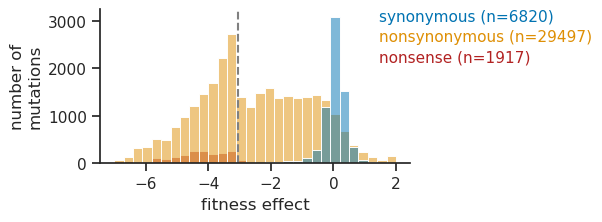

In [43]:
mut_class_colors = {
    'synonymous' : '#0173b2',
    'nonsynonymous' : '#de8f05',
    'nonsense' : 'firebrick',
}

count_threshold = 10
data = fitness_df[
    (fitness_df['expected_count'] >= count_threshold) |
    (fitness_df['actual_count'] >= count_threshold)
].copy()
print(f'expected or actual count >= {count_threshold}\nN = {len(data)}')
fitness_lod = np.log(0.5/(count_threshold+0.5))
data['delta_fitness'] = data['delta_fitness'].clip(upper=2, lower=-7)
plt.figure(figsize=(4,2))
ax = sns.histplot(
    x='delta_fitness', data=data, bins=30,
    hue='mut_class', hue_order=['synonymous', 'nonsynonymous', 'nonsense'],
    palette=mut_class_colors
)

# Annotate the number of mutations in each class
for (i, mut_class) in enumerate(['synonymous', 'nonsynonymous', 'nonsense']):
    count = (data['mut_class'] == mut_class).sum()
    median_fitness = data.loc[data['mut_class'] == mut_class, 'delta_fitness'].median()
    ax.text(
        0.9, 0.9-i*0.13, f'{mut_class} (n={count})', ha='left', va='bottom',
        color=mut_class_colors[mut_class], fontsize=11, transform=ax.transAxes,
    )

ax.get_legend().remove()
plt.axvline(fitness_lod, color='gray', linestyle='--')
plt.xlabel('fitness effect')
plt.ylabel('number of\nmutations')
sns.despine()
plt.show()

Plot distributions of fitness effects as a function of gene.

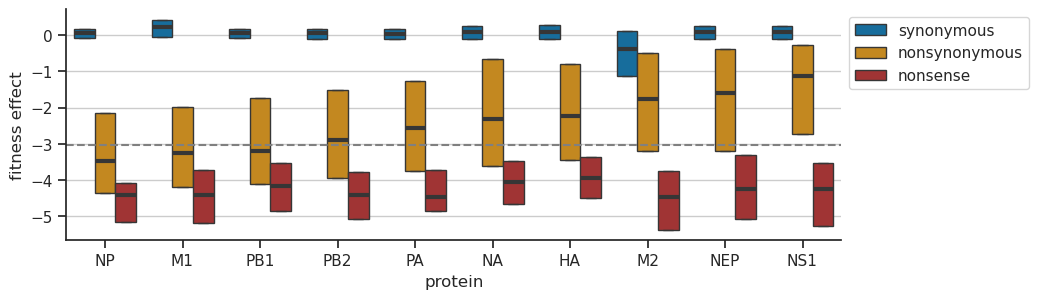

In [44]:
# Get data
count_threshold = 10
data = fitness_df[
    (fitness_df['expected_count'] >= count_threshold) |
    (fitness_df['actual_count'] >= count_threshold)
].copy()
fitness_lod = np.log(0.5/(count_threshold+0.5))

# Explode dataframe so that there is one row per mutation per gene
data['gene'] = data['gene'].str.split(';')
data['codon_site'] = data['codon_site'].str.split(';')
data = data.explode(['gene', 'codon_site'])

# Sort dataframe by median delta_fitness of nonsynonymous mutations
nonsynonymous_medians = (
    data[data['mut_class'] == 'nonsynonymous']
    .groupby('gene', as_index=False)['delta_fitness']
    .median()
    .sort_values('delta_fitness')
    .rename(columns={'delta_fitness':'median_nonsyn_fitness'})
)
data = (
    data
    .merge(nonsynonymous_medians)
    .sort_values('median_nonsyn_fitness', ascending=True)
)

# Plot data
plt.figure(figsize=[10,3])
sns.boxplot(
    x='gene', y='delta_fitness', data=data,
    hue='mut_class', hue_order=['synonymous', 'nonsynonymous', 'nonsense'],
    palette=mut_class_colors,
    medianprops={"linewidth": 3}, showfliers=False, whis=(50,50)
)
plt.axhline(fitness_lod, color='gray', linestyle='--')
plt.grid(axis='y')
plt.legend(bbox_to_anchor=(1,1))
plt.xlabel('protein')
plt.ylabel('fitness effect')
sns.despine()
plt.show()

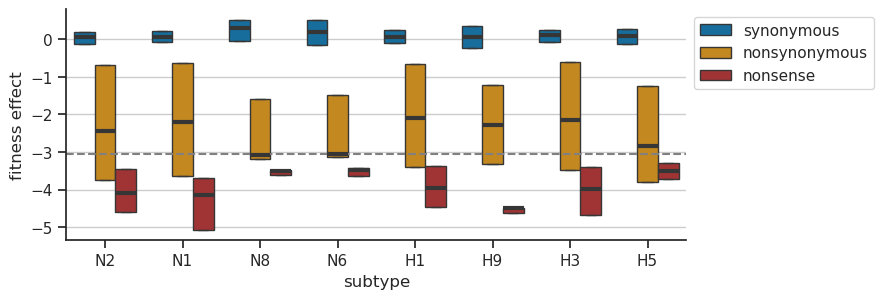

In [45]:
# Get data for HA/NA subtypes with at least 100 mutations with estimated fitness effects
ha_na_data = data[data['gene'].isin(['HA', 'NA'])].copy()
subtype_counts = ha_na_data['subtype'].value_counts()
subtypes_to_include = subtype_counts[subtype_counts >= 100].index
ha_na_data = ha_na_data[ha_na_data['subtype'].isin(subtypes_to_include)]

# Plot distributions for different HA and NA subtypes
plt.figure(figsize=[8,3])
sns.boxplot(
    x='subtype', y='delta_fitness', data=ha_na_data,
    hue='mut_class', hue_order=['synonymous', 'nonsynonymous', 'nonsense'],
    palette=mut_class_colors,
    medianprops={"linewidth": 3}, showfliers=False, whis=(50,50)
)
plt.axhline(fitness_lod, color='gray', linestyle='--')
plt.grid(axis='y')
plt.legend(bbox_to_anchor=(1,1))
plt.ylabel('fitness effect')
sns.despine()
plt.show()

Examine the fitness effects of synonymous mutation across the genome.

In [46]:
# Load packaging signal boundaries
packaging_signals = pd.read_csv('../data/packaging_signal_boundaries.csv', keep_default_na=False)

# Determine CDS length per segment from coding_sites.csv
# Use H1 for HA, N1 for NA, 'all' for internal segments
segment_subtypes = {
    'PB2': 'all', 'PB1': 'all', 'PA': 'all', 'HA': 'H1',
    'NP': 'all', 'NA': 'N1', 'MP': 'all', 'NS': 'all'
}
cds_lengths = {}
for segment, subtype in segment_subtypes.items():
    coding_sites = pd.read_csv(f'../results/{segment}/{subtype}/coding_sites.csv', keep_default_na=False)
    cds_lengths[segment] = coding_sites['site'].max()

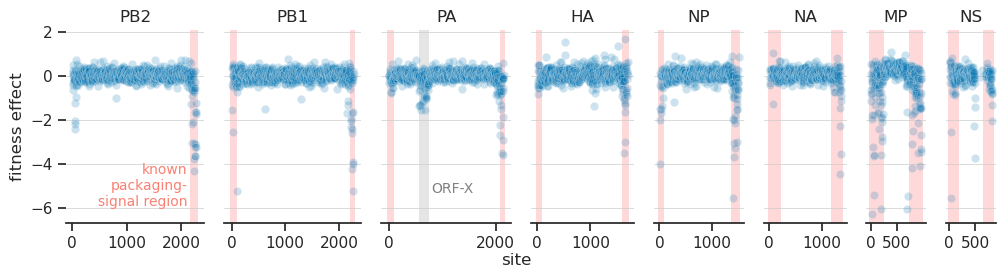

In [47]:
# Get data, subsetting HA to H1 and NA to N1
count_threshold = 25
syn_data = site_syn_fitness_df[
    (site_syn_fitness_df['expected_count'] >= count_threshold) &
    (site_syn_fitness_df['subtype'].isin(['all', 'H1', 'N1']))
].copy()

# Get width ratios from CDS lengths
segments = ['PB2', 'PB1', 'PA', 'HA', 'NP', 'NA', 'MP', 'NS']
width_ratios = [cds_lengths[segment] for segment in segments]

# Plot data
(fig, axs) = plt.subplots(
    ncols=len(segments), sharey=True, figsize=[12, 2.5],
    gridspec_kw={'width_ratios': width_ratios}
)
for (i, segment) in enumerate(segments):
    ax = axs[i]
    data = syn_data[syn_data['segment'] == segment]
    sns.scatterplot(
        x='site', y='delta_fitness', data=data, ax=ax, alpha=0.2,
        color=mut_class_colors['synonymous']
    )

    # Add shaded packaging signal regions
    cds_len = cds_lengths[segment]
    for _, row in packaging_signals[packaging_signals['segment'] == segment].iterrows():
        if row['nt'] == 0:
            continue
        if row['end'] == '3prime_vRNA':
            x_start, x_end = 1, row['nt']
        else:  # 5prime_vRNA
            x_start, x_end = cds_len - row['nt'] + 1, cds_len
        # increase shaded region to mostly overlap with dots in region
        buffer = 30
        x_start -= buffer
        x_end += buffer
        ax.axvspan(x_start, x_end, alpha=0.15, color='red', zorder=0, lw=0)

    # Add PA-X X-ORF annotation for PA subplot
    # Coordinates from CY121122 reference (flu-usher results_260226/PA/all/curated_reference.fasta)
    # PA-X = join(1..570, 572..760); X-ORF (+1 frame) nt 572-760, stop codon TGA at 758-760
    # Reference: Jagger et al. 2012 Science
    if segment == 'PA':
        ax.axvspan(572, 760, alpha=0.2, color='gray', zorder=0, lw=0)
        x_center = (572 + 760) / 2 / cds_len
        ax.text(0.55, 0.21, 'ORF-X', transform=ax.transAxes,
                ha='center', va='top', fontsize=10, color='gray')

    # Annotate leftmost plot with packaging signal legend
    if i == 0:
        ax.text(0.88, 0.07, 'known\npackaging-\nsignal region', transform=ax.transAxes,
                ha='right', va='bottom', fontsize=10, color='salmon')

    ax.grid(axis='y', which='both', lw=0.5)
    ax.set(title=segment, xlabel='')
    if i > 0:
        ax.tick_params(axis='y', which='both', left=False, labelleft=False)
    if segment in ['MP', 'NS']:
        ax.set(xticks=[0, 500])
    sns.despine(left=True, ax=ax)

axs[0].set(ylabel='fitness effect')
fig.text(0.5, -0.06, 'site', ha='center')
plt.show()

Zoom in on the ends of a specific segment.

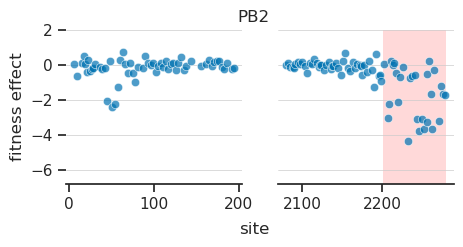

In [48]:
segment = 'PB2'
data = syn_data[(syn_data['segment'] == segment)]
cds_len = cds_lengths[segment]

left_site_range = (0, 200)
right_site_range = (data['site'].max()-200, data['site'].max()+1)
(fig, axs) = plt.subplots(ncols=2, sharey=True, figsize=[5,2])

left_data = data[data['site'].between(*left_site_range)]
right_data = data[data['site'].between(*right_site_range)]
sns.scatterplot(x='site', y='delta_fitness', data=left_data, alpha=0.7, ax=axs[0])
sns.scatterplot(x='site', y='delta_fitness', data=right_data, alpha=0.7, ax=axs[1])

# Shade 3'-vRNA signal on left plot, 5'-vRNA signal on right plot
for _, row in packaging_signals[packaging_signals['segment'] == segment].iterrows():
    if row['nt'] == 0:
        continue
    if row['end'] == '3prime_vRNA':
        axs[0].axvspan(1, row['nt'], alpha=0.15, color='red', zorder=0, lw=0)
    else:  # 5prime_vRNA
        x_start = cds_len - row['nt'] + 1
        axs[1].axvspan(x_start, cds_len, alpha=0.15, color='red', zorder=0, lw=0)

axs[0].grid(axis='y', which='both', lw=0.5)
axs[1].grid(axis='y', which='both', lw=0.5)

axs[0].set(ylabel='fitness effect', xlabel='', ylim=[-6.8,2])
axs[1].set(xlabel='')
plt.figtext(0.5, -0.14, 'site', ha='center')
plt.suptitle(segment, fontsize=12)

sns.despine(left=True, ax=axs[0])
axs[1].tick_params(axis='y', which='both', left=False, labelleft=False)
sns.despine(left=True, ax=axs[1])

plt.show()

Zoom in on the MP segment.

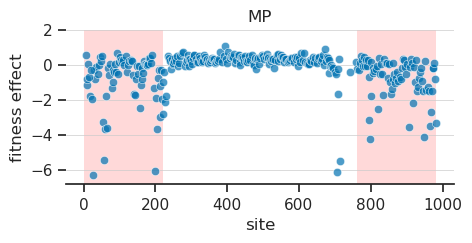

In [49]:
segment = 'MP'
data = syn_data[(syn_data['segment'] == segment)]
cds_len = cds_lengths[segment]

plt.figure(figsize=[5,2])
ax = plt.gca()
sns.scatterplot(x='site', y='delta_fitness', data=data, alpha=0.7, ax=ax)

# Add shaded packaging signal regions
for _, row in packaging_signals[packaging_signals['segment'] == segment].iterrows():
    if row['nt'] == 0:
        continue
    if row['end'] == '3prime_vRNA':
        x_start, x_end = 1, row['nt']
    else:  # 5prime_vRNA
        x_start, x_end = cds_len - row['nt'] + 1, cds_len
    ax.axvspan(x_start, x_end, alpha=0.15, color='red', zorder=0, lw=0)

plt.grid(axis='y', which='both', lw=0.5)
plt.ylim([-6.8,2])
plt.ylabel('fitness effect')
plt.title(segment)
sns.despine(left=True)
plt.show()

## Compare estimated fitness effects to experimentally measured DMS data

Read in data on HA.

In [50]:
# Get fitness data
count_threshold_dms_comparison = 25
ha_fitness_data = fitness_df[
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['gene'] == 'HA') &
    (fitness_df['subtype'] == 'H3')
].copy()
ha_fitness_data['codon_site'] = ha_fitness_data['codon_site'].astype(int)

# Read in processed DMS data and merge with fitness data
ha_dms_data = pd.read_csv('../results/dms_data/Yu_HA/processed_dms_data.csv')
ha_dms_data = (
    ha_dms_data
    .rename(columns={'tree_reference_site' : 'codon_site'})
    .merge(ha_fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(ha_dms_data))
print('N sites with data:', ha_dms_data['codon_site'].nunique())
ha_dms_data.head()

N muts with data: 1304
N sites with data: 503


,site,wt_aa,mut_aa,sera_escape,dms_effect,pH_stability,sequential_site,n_nt_changes,codon_site,reference_site,sequential_wt,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
0,1,Q,K,0.04918,-0.11150,0.001008,1,1,17,1,Q,all,H3,HA,HA,Q17K,nonsynonymous,53,39.353781,0.294464
1,1,Q,R,-0.19230,-0.88610,0.012610,1,1,17,1,Q,all,H3,HA,HA,Q17R,nonsynonymous,18,44.253182,-0.883392
2,2,K,E,-0.06889,-0.31980,0.050210,2,1,18,2,K,all,H3,HA,HA,K18E,nonsynonymous,73,75.151576,-0.028853
3,2,K,R,-0.10240,-0.61280,0.060580,2,1,18,2,K,all,H3,HA,HA,K18R,nonsynonymous,63,75.288559,-0.176907
4,3,I,M,-0.01625,0.07985,0.028840,3,1,19,3,I,all,H3,HA,HA,I19M,nonsynonymous,40,53.527190,-0.288185


Read in data for NP.

In [51]:
# Get fitness data
np_fitness_data = fitness_df[
    (fitness_df['gene'] == 'NP') &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['subtype'] == 'all')
].copy()
np_fitness_data['codon_site'] = np_fitness_data['codon_site'].astype(int)

# Read in data and merge with fitness data. The sites are indexed in the exact same way.
np_dms_data = (
    pd.read_csv('../results/dms_data/Bloom_NP/processed_dms_data.csv')
    .rename(columns={'site':'codon_site'})
    .merge(np_fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(np_dms_data))
print('N sites with data:', np_dms_data['codon_site'].nunique())
np_dms_data

N muts with data: 1878
N sites with data: 485


,codon_site,wt_aa,mut_aa,preference,wt_preference,dms_effect,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
1246,1,M,R,0.028061,0.391903,-2.636616,all,all,NP,NP,M1R,nonsynonymous,0,26.097414,-3.973961
1522,1,M,T,0.032492,0.391903,-2.490014,all,all,NP,NP,M1T,nonsynonymous,0,128.096325,-5.549825
551,1,M,I,0.023434,0.391903,-2.816809,all,all,NP,NP,M1I,nonsynonymous,0,353.334889,-6.561978
695,1,M,K,0.038531,0.391903,-2.319554,all,all,NP,NP,M1K,nonsynonymous,0,38.950619,-4.368197
1523,2,A,T,0.004529,0.753436,-5.114244,all,all,NP,NP,A2T,nonsynonymous,9,465.017661,-3.891858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1655,498,N,T,0.063578,0.088315,-0.328635,all,all,NP,NP,N498T,nonsynonymous,3,29.771859,-2.157456
694,498,N,I,0.073817,0.088315,-0.179316,all,all,NP,NP,N498I,nonsynonymous,17,30.677895,-0.577508
852,498,N,K,0.276824,0.088315,1.142474,all,all,NP,NP,N498K,nonsynonymous,12,42.019540,-1.224235
1877,498,N,Y,0.011276,0.088315,-2.058196,all,all,NP,NP,N498Y,nonsynonymous,5,27.240008,-1.618128


Read in data for PB2.

In [52]:
# Get fitness data
fitness_data = fitness_df[
    (fitness_df['gene'] == 'PB2') &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['subtype'] == 'all')
].copy()
fitness_data['codon_site'] = fitness_data['codon_site'].astype(int)

# Read in the DMS data and merge with the fitness data
pb2_dms_data = (
    pd.read_csv('../data/dms_data/Soh_PB2/elife-45079-fig2-data1-v1.csv')
    .rename(columns={
        'site':'codon_site',
        'wildtype' : 'wt_aa', 
        'mutation' : 'mut_aa',
        'log2effectA549': 'dms_effect'
    })
    .merge(fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(pb2_dms_data))
print('N sites with data:', pb2_dms_data['codon_site'].nunique())
pb2_dms_data.head()

N muts with data: 2660
N sites with data: 757


,codon_site,wt_aa,mut_aa,prefA549,prefCCL141,log2prefA549,log2prefCCL141,effectA549,effectCCL141,dms_effect,...,Experimentally adaptive in,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
1032,1,M,K,0.045065,0.042917,-4.471848,-4.542299,0.091968,0.118499,-3.442719,...,NaN,all,all,PB2,PB2,M1K,nonsynonymous,0,30.143002,-4.115551
2238,1,M,T,0.037434,0.052167,-4.739489,-4.260707,0.076396,0.144040,-3.710360,...,NaN,all,all,PB2,PB2,M1T,nonsynonymous,0,112.852565,-5.423650
793,1,M,I,0.051935,0.048641,-4.267144,-4.361682,0.105989,0.134303,-3.238015,...,NaN,all,all,PB2,PB2,M1I,nonsynonymous,0,298.703127,-6.394270
1033,2,E,K,0.023902,0.043219,-5.386741,-4.532198,0.129111,0.277256,-2.953314,...,NaN,all,all,PB2,PB2,E2K,nonsynonymous,11,417.928937,-3.594160
177,2,E,D,0.050450,0.051871,-4.308996,-4.268940,0.272519,0.332758,-1.875570,...,NaN,all,all,PB2,PB2,E2D,nonsynonymous,16,30.284467,-0.623650


Read in data for NA.

In [53]:
# Get fitness data
na_fitness_data = fitness_df[
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['gene'] == 'NA') &
    (fitness_df['subtype'] == 'N1')
].copy()
na_fitness_data['codon_site'] = na_fitness_data['codon_site'].astype(int)

# Read in data and merge with fitness data. The sites are indexed in the exact same way.
na_dms_data = (
    pd.read_csv('../results/dms_data/Wang_NA/processed_dms_data.csv')
    .rename(columns={'tree_reference_site' : 'codon_site'})
    .merge(na_fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(na_dms_data))
print('N sites with data:', na_dms_data['codon_site'].nunique())
na_dms_data

N muts with data: 876
N sites with data: 341


,dms_site,wt_aa,mut_aa,codon_site,dms_effect,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
0,7,I,M,7,-1.468916,all,N1,NA,NA,I7M,nonsynonymous,24,139.059431,-1.739817
1,8,I,L,8,-2.304362,all,N1,NA,NA,I8L,nonsynonymous,13,35.568305,-0.982725
2,8,I,V,8,-0.997490,all,N1,NA,NA,I8V,nonsynonymous,20,108.960808,-1.675142
3,8,I,T,8,-0.425550,all,N1,NA,NA,I8T,nonsynonymous,91,162.688604,-0.578568
4,8,I,M,8,-0.949175,all,N1,NA,NA,I8M,nonsynonymous,45,128.699230,-1.043643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,406,F,S,407,-2.372462,all,N1,NA,NA,F407S,nonsynonymous,3,147.232241,-3.742638
872,406,F,L,407,-2.546067,all,N1,NA,NA,F407L,nonsynonymous,2,188.427740,-4.325074
873,407,W,R,408,-2.351493,all,N1,NA,NA,W408R,nonsynonymous,1,93.962936,-4.142742
874,407,W,R,408,-4.840724,all,N1,NA,NA,W408R,nonsynonymous,1,93.962936,-4.142742


Read in data for PB1.

In [54]:
# Get fitness data
pb1_fitness_data = fitness_df[
    (fitness_df['gene'] == 'PB1') &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['subtype'] == 'all')
].copy()
pb1_fitness_data['codon_site'] = pb1_fitness_data['codon_site'].astype(int)

# Read in processed DMS data and merge with fitness data
pb1_dms_data = (
    pd.read_csv('../results/dms_data/Li_PB1/processed_dms_data.csv')
    .rename(columns={'tree_reference_site': 'codon_site'})
    .merge(pb1_fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(pb1_dms_data))
print('N sites with data:', pb1_dms_data['codon_site'].nunique())
pb1_dms_data.head()

N muts with data: 1170
N sites with data: 621


,dms_site,wt_aa,mut_aa,codon_site,dms_effect,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
0,1,M,I,1,-0.859333,all,all,PB1,PB1,M1I,nonsynonymous,0,242.118556,-6.184638
1,1,M,K,1,-0.511153,all,all,PB1,PB1,M1K,nonsynonymous,0,25.422883,-3.948273
2,2,D,N,2,-0.940369,all,all,PB1,PB1,D2N,nonsynonymous,12,343.759017,-3.315666
3,2,D,E,2,-0.778942,all,all,PB1,PB1,D2E,nonsynonymous,4,44.353864,-2.299332
4,2,D,G,2,-0.755760,all,all,PB1,PB1,D2G,nonsynonymous,7,235.589315,-3.449307


Read in data for M1.

In [55]:
# Get fitness data
m1_fitness_data = fitness_df[
    (fitness_df['gene'] == 'M1') &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['subtype'] == 'all')
].copy()
m1_fitness_data['codon_site'] = m1_fitness_data['codon_site'].astype(int)

# Read in processed DMS data and merge with fitness data
m1_dms_data = (
    pd.read_csv('../results/dms_data/Hom_M1/processed_dms_data.csv')
    .rename(columns={'tree_reference_site': 'codon_site'})
    .merge(m1_fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(m1_dms_data))
print('N sites with data:', m1_dms_data['codon_site'].nunique())
m1_dms_data.head()

N muts with data: 803
N sites with data: 227


,dms_site,wt_aa,mut_aa,codon_site,dms_effect,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
206,10,Y,H,10,-2.353206,all,all,MP,M1,Y10H,nonsynonymous,4,272.708638,-4.106158
32,10,Y,C,10,-2.614879,all,all,MP,M1,Y10C,nonsynonymous,1,319.885419,-5.364060
130,11,V,F,11,-3.380181,all,all,MP,M1,V11F,nonsynonymous,1,103.577735,-4.239673
0,11,V,A,11,-0.696849,all,all,MP,M1,V11A,nonsynonymous,4,177.831261,-3.679565
231,11,V,I,11,-2.755224,all,all,MP,M1,V11I,nonsynonymous,3,562.595542,-5.080686


Read in data for NEP.

In [56]:
# Get fitness data
# NEP overlaps NS1; gene, codon_site, wt_aa, and mut_aa are all stored as
# ';'-joined strings for overlapping mutations. Explode all four columns together
# to extract the NEP-specific values.
nep_fitness_data = fitness_df[
    fitness_df['gene'].str.contains('NEP') &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['subtype'] == 'all')
].copy()

for col in ['gene', 'codon_site', 'wt_aa', 'mut_aa']:
    nep_fitness_data[col] = nep_fitness_data[col].str.split(';')
nep_fitness_data = nep_fitness_data.explode(['gene', 'codon_site', 'wt_aa', 'mut_aa'])

# Keep only NEP rows where the mutation is nonsynonymous in NEP
nep_fitness_data = nep_fitness_data[
    (nep_fitness_data['gene'] == 'NEP') &
    (nep_fitness_data['wt_aa'] != nep_fitness_data['mut_aa'])
].copy()
nep_fitness_data['codon_site'] = nep_fitness_data['codon_site'].astype(int)

# Read in processed DMS data and merge with fitness data
nep_dms_data = (
    pd.read_csv('../results/dms_data/Teo_NEP/processed_dms_data.csv')
    .rename(columns={'tree_reference_site': 'codon_site'})
    .merge(nep_fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(nep_dms_data))
print('N sites with data:', nep_dms_data['codon_site'].nunique())
nep_dms_data.head()

N muts with data: 333
N sites with data: 106


,dms_site,wt_aa,mut_aa,codon_site,dms_effect,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
0,2,D,E,2,0.023601,all,all,NS,NEP,D2E;D2E,nonsynonymous,47,37.040020,0.235322
1,2,D,G,2,0.248671,all,all,NS,NEP,D2G;D2G,nonsynonymous,12,236.426505,-2.942021
2,2,D,N,2,0.404429,all,all,NS,NEP,D2N;D2N,nonsynonymous,160,392.819679,-0.896329
3,4,N,D,4,-0.465135,all,all,NS,NEP,N4D;N4D,nonsynonymous,12,79.529815,-1.856671
4,4,N,S,4,0.127127,all,all,NS,NEP,N4S;N4S,nonsynonymous,33,186.574914,-1.719964


0.1716462255984617


<Axes: xlabel='dms_effect', ylabel='delta_fitness'>

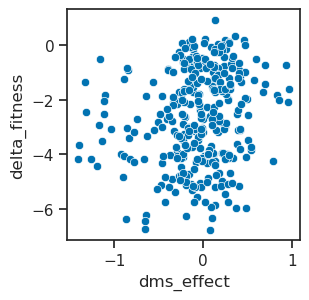

In [57]:
data = nep_dms_data # nep_dms_data[nep_dms_data['codon_site'].between(100,111)]
print(data['dms_effect'].corr(data['delta_fitness']))
plt.figure(figsize=[3,3])
sns.scatterplot(x='dms_effect', y='delta_fitness', data=data)

Read in data for PA.

In [58]:
# Get fitness data for PA
pa_fitness_data = fitness_df[
    (fitness_df['gene'] == 'PA') &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['subtype'] == 'all')
].copy()
pa_fitness_data['codon_site'] = pa_fitness_data['codon_site'].astype(int)

# Read in processed DMS data and merge with fitness data
pa_dms_data = (
    pd.read_csv('../results/dms_data/Chen_PA/processed_dms_data.csv')
    .rename(columns={'tree_reference_site': 'codon_site'})
    .merge(pa_fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(pa_dms_data))
print('N sites with data:', pa_dms_data['codon_site'].nunique())
pa_dms_data.head()

N muts with data: 465
N sites with data: 225


,dms_site,wt_aa,mut_aa,codon_site,dms_effect,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
0,1,M,I,1,-2.235865,all,all,PA,PA,M1I,nonsynonymous,0,306.662126,-6.420523
1,2,E,D,2,-1.132207,all,all,PA,PA,E2D,nonsynonymous,6,52.198396,-2.092783
2,4,F,L,4,-0.058706,all,all,PA,PA,F4L,nonsynonymous,73,207.268156,-1.039137
3,4,F,S,4,-2.619114,all,all,PA,PA,F4S,nonsynonymous,4,161.958517,-3.586345
4,5,V,A,5,-1.682286,all,all,PA,PA,V5A,nonsynonymous,16,108.731114,-1.890106


Summary plot comparing DMS effects and fitness effects

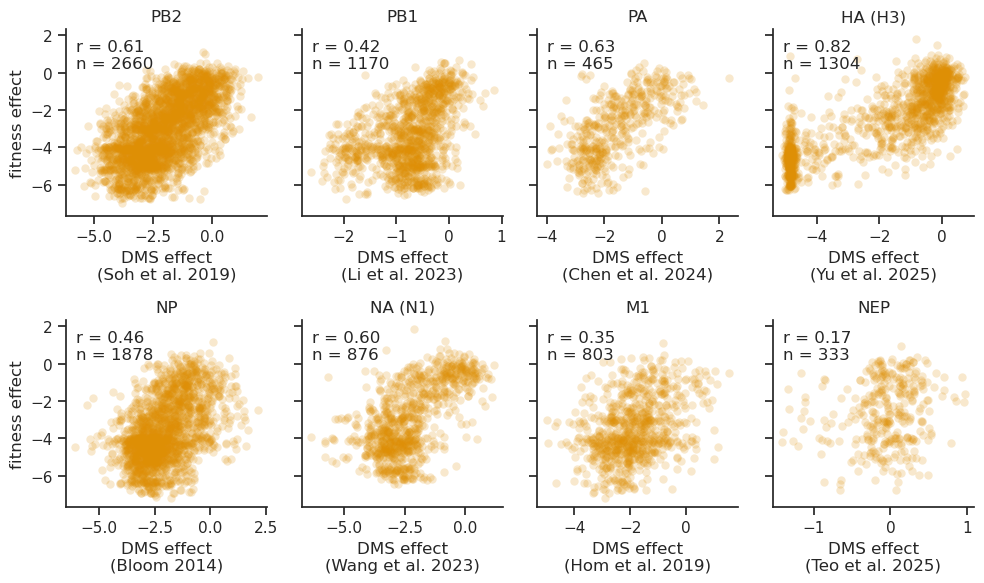

In [59]:
datasets = [
    ('PB2', pb2_dms_data),
    ('PB1', pb1_dms_data),
    ('PA', pa_dms_data),
    ('HA (H3)',  ha_dms_data),
    ('NP',  np_dms_data),
    ('NA (N1)',  na_dms_data),
    ('M1',  m1_dms_data),
    ('NEP', nep_dms_data),
]
author_year = {
    'HA (H3)' : 'Yu et al. 2025',
    'NP' : 'Bloom 2014',
    'M1' : 'Hom et al. 2019',
    'NEP' : 'Teo et al. 2025',
    'PB1' : 'Li et al. 2023',
    'PA' : 'Chen et al. 2024',
    'PB2' : 'Soh et al. 2019',
    'NA (N1)' : 'Wang et al. 2023',
}

fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(10, 6), sharey=True)
axs = axs.flatten()

fitness_lod = np.log(0.5/(count_threshold_dms_comparison+0.5))
for ax, (label, df) in zip(axs, datasets):
    r = df['dms_effect'].corr(df['delta_fitness'])
    n = len(df)
    sns.scatterplot(
        x='dms_effect', y='delta_fitness', data=df,
        c=mut_class_colors['nonsynonymous'], alpha=0.2, linewidth=0, ax=ax
    )
    # ax.axhline(fitness_lod, color='gray', linestyle='--')
    ax.annotate(f'r = {r:.2f}\nn = {n}', xy=(0.05, 0.95), xycoords='axes fraction', va='top')
    ax.set(
        title=label, xlabel=f'DMS effect\n({author_year[label]})',
        ylabel='fitness effect'
    )
    sns.despine(ax=ax)


plt.tight_layout()
plt.show()

In [60]:
pb1_dms_data[
    (pb1_dms_data['delta_fitness'] < -4) &
    (pb1_dms_data['dms_effect'] > -1)
][['codon_site', 'wt_aa', 'mut_aa', 'dms_effect', 'delta_fitness']]

,codon_site,wt_aa,mut_aa,dms_effect,delta_fitness
0,1,M,I,-0.859333,-6.184638
5,4,N,D,0.060052,-4.995365
7,5,P,L,-0.664120,-4.066001
21,15,Q,R,-0.669634,-5.016383
24,17,A,T,-0.520483,-4.833347
...,...,...,...,...,...
1112,725,D,E,-0.728328,-4.441839
1113,725,D,G,-0.419209,-4.213878
1129,732,S,P,-0.634946,-4.999176
1157,747,C,Y,-0.559514,-6.175527
